In [129]:
%reload_ext autoreload
%autoreload 2

In [130]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [131]:
from waymo_agent.notebook_imports import *

In [132]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from kret_sandbox.VIS import dtt

In [133]:
config = EnvConfig()
plt_cfg = PlotConfig()

In [134]:
env = RideShareEnv(config, plt_cfg)
G = env.G
cfg = env.config

Assigned lambda values to nodes. Total lambda: 0.2282 (target: 0.2346)


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [135]:
price_agent = PricingAgent(env.config)
dispatch_agent = DispatchAgent(env.config)
reposition_agent = RepositionAgent(env)

In [136]:
obs, info = env.reset()

In [137]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

In [138]:
veh, req, rides = get_obvs_tuple(env)
veh.shape, req.shape, rides.shape

((3, 6), (5, 21), (3, 18))

In [139]:
action_rnd = env.action_space.sample()
dispatches = pd.DataFrame({"dispatch": action_rnd["dispatch"]})
prices = pd.DataFrame({"prices": action_rnd["prices"]})
reposition = pd.DataFrame(action_rnd["reposition"], columns=["x", "y"])
# action_rnd["dispatch"] = np.full(action_rnd["dispatch"].shape, cfg.no_action_id, dtype=np.int32)
# action_rnd["reposition"] = np.array([[-0.1, -0.1], [0.1, 0.1]], dtype=np.float32)
env.action_space.contains(action_rnd)

True

In [140]:
veh.shape

(3, 6)

## Pre-Step

In [469]:
req_obs = RequestDF(RequestDF.from_obs_numpy(obs["pending_requests"]))
veh_obs = VehicleDF(VehicleDF.from_obs_numpy(obs["vehicles"]))
rides_obs = ActiveRideDF(ActiveRideDF.from_obs_numpy(obs["active_rides"]))
dtt(
    [req_obs, req_obs.f_valid, req_obs.f_awaiting_price, req_obs.f_need_dispatch],
    10,
    titles=["Pending Requests After Step", "f_valid", "f_awaiting_price", "f_need_dispatch"],
)

Pending Requests After Step 
 
 
 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_x_norm 
 dropoff_y_norm 
 distance_meters 
 est_cost 
 max_wait_time 
 wait_time 
 status 
 
 
 
 
 0 
 -0.00835 
 -0.688786 
 0.202396 
 0.037523 
 5830.377529 
 5.830378 
 0 days 00:15:00 
 0 days 00:01:00 
 1 
 
 
 1 
 0.474258 
 0.472829 
 0.084569 
 0.074323 
 3954.550331 
 3.95455 
 0 days 00:15:00 
 0 days 00:06:00 
 3 
 
 
 2 
 0.283783 
 0.082449 
 0.791492 
 0.717062 
 5812.455762 
 5.812456 
 0 days 00:15:00 
 0 days 00:07:00 
 3 
 
 
 3 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaT 
 -10 
 
 
 4 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaT 
 -10 
 
 
 f_valid 
 
 
 
 0 
 
 
 
 
 0 
 True 
 
 
 1 
 True 
 
 
 2 
 True 
 
 
 3 
 False 
 
 
 4 
 False 
 
 
 f_awaiting_price 
 
 
 
 0 
 
 
 
 
 0 
 False 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False 
 
 
 f_need_dispatch 
 
 
 
 0 
 
 
 
 
 0 
 True 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False

In [470]:
dtt([veh_obs, rides_obs], 10, titles=["Vehicles", "Active Rides"])

Vehicles 
 
 
 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 
 
 
 
 0 
 0.069 
 -0.164 
 0.770 
 0.0 
 
 
 1 
 0.277 
 0.202 
 0.938 
 2.0 
 
 
 2 
 0.321 
 0.134 
 0.715 
 2.0 
 
 
 Active Rides 
 
 
 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 
 
 
 
 0 
 -1.000 
 -1.000 
 -1.000 
 -1.000 
 -1.000 
 -1.000 
 -1.000000 
 -1.000000 
 -1.000000 
 
 
 1 
 0.474 
 0.473 
 0.085 
 0.074 
 7.398 
 3.955 
 3954.550049 
 1991.709961 
 3954.550049 
 
 
 2 
 0.284 
 0.082 
 0.791 
 0.717 
 7.398 
 5.812 
 5812.456055 
 5735.037109 
 5812.456055

In [716]:
prices = price_agent.price(obs)
dispatch_actions = dispatch_agent.dispatch(obs)
reposition_actions = reposition_agent.reposition(obs)

prices_df = pd.DataFrame({"prices": prices})
dispatch_df = pd.DataFrame({"dispatch": dispatch_actions})
reposition_df = pd.DataFrame(reposition_actions, columns=["x", "y"])

action_agent: ActionDict = {
    "prices": prices,
    "dispatch": dispatch_actions,
    "reposition": reposition_actions,
}

Dispatchable requests: 0 out of 5


In [717]:
dtt([prices_df, dispatch_df, reposition_df], titles=["Prices", "Dispatch", "Reposition"])

,prices
0,8.195
1,0.000
2,0.000
3,0.000
4,0.000
,dispatch
0,-1
1,-1
2,-1
3,-1


In [718]:
dtt([veh, rides], n=12, how="head", titles=["Vehicles", "Rides"])

Vehicles 
 
 
 
 vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 0 
 0 
 -0.426 
 -0.007 
 0.770 
 0 
 -1 
 
 
 1 
 1 
 0.177 
 0.654 
 0.938 
 2 
 10 
 
 
 2 
 2 
 0.076 
 0.158 
 0.715 
 2 
 9 
 
 
 Rides 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 0 
 -1 
 0 
 -1 
 -1.000 
 -1.000 
 -1 
 -1.000 
 -1.000 
 -1.000 
 -1.000 
 -1.000000 
 -1.000000 
 -1.000000 
 [] 
 -1 
 -1 
 -1.000000 
 False 
 
 
 1 
 10 
 1 
 42443950 
 -0.055 
 -0.073 
 42442584 
 0.366 
 0.914 
 10.431 
 8.195 
 8194.593750 
 2454.149902 
 8194.593750 
 [42443950, 42437358, 42432693, 42434072, 42432580, 42440153, 42430358, 42430367, 42430371, 42440015, 42440022, 42428329, 1825841743, 1825841704, 1825841655, 42428575, 42428588, 13208007103, 6173564360, 1061531707, 1061531491, 6207264908, 42432564, 42442451, 42442463, 42442469, 42442480, 42442534, 42421741, 42442569, 42442584] 
 42442534 
 42421741 
 348.716003 
 False 
 
 
 2 
 9 
 2 
 6223571522 
 0.270 
 0.860 
 42448317 
 0.155 
 0.123 
 9.406 
 6.261 
 6260.535156 
 632.185974 
 6260.535156 
 [6223571522, 6223571524, 6223571523, 42428782, 42421745, 42428714, 42428711, 42428674, 42428653, 42428634, 9177424867, 42428595, 1061531707, 6173564360, 13208007103, 1061531509, 1825841742, 4347550065, 4347550071, 4347550074, 42423674, 42430394, 4347534767, 5706568771, 42445950, 596775946, 42448317] 
 42430394 
 4347534767 
 141.837006 
 False

In [719]:
dtt([req], titles=["Valid Requests"])

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters
0,10,2025-01-03 13:17:59.966535,33622,-0.357,2.044,8.195,10.431,0 days 00:15:00,0 days 00:14:00,3,42443950,-0.055,-0.073,42442584,0.366,0.914,"[42443950, 42437358, 42432693, 42434072, 42432580, 42440153, 42430358, 42430367, 42430371, 42440015, 42440022, 42428329, 1825841743, 1825841704, 1825841655, 42428575, 42428588, 13208007103, 6173564360, 1061531707, 1061531491, 6207264908, 42432564, 42442451, 42442463, 42442469, 42442480, 42442534, 42421741, 42442569, 42442584]",42443950,42437358.0,0.0,8194.594
1,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1.0,-1.0,-1.000
2,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1.0,-1.0,-1.000
3,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1.0,-1.0,-1.000
4,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1.0,-1.0,-1.000


# Take Step

In [720]:
env.config.max_new_requests_per_step = 2

In [721]:
obs, reward, trunc, term, info = env.step(action_agent)
req_obs = RequestDF(RequestDF.from_obs_numpy(obs["pending_requests"]))
req_obs.f_awaiting_price.sum()

resetting debug and interim dataframes


np.int64(0)

In [722]:
req_obs = RequestDF(RequestDF.from_obs_numpy(obs["pending_requests"]))
veh_obs = VehicleDF(VehicleDF.from_obs_numpy(obs["vehicles"]))
rides_obs = ActiveRideDF(ActiveRideDF.from_obs_numpy(obs["active_rides"]))
dtt(
    [req_obs, req_obs.f_valid, req_obs.f_awaiting_price, req_obs.f_need_dispatch],
    10,
    titles=["Pending Requests After Step", "f_valid", "f_awaiting_price", "f_need_dispatch"],
)

Pending Requests After Step 
 
 
 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_x_norm 
 dropoff_y_norm 
 distance_meters 
 est_cost 
 max_wait_time 
 wait_time 
 status 
 
 
 
 
 0 
 -0.055399 
 -0.072642 
 0.365626 
 0.913902 
 8194.593817 
 8.194594 
 0 days 00:15:00 
 0 days 00:15:00 
 3 
 
 
 1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaT 
 -10 
 
 
 2 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaT 
 -10 
 
 
 3 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaT 
 -10 
 
 
 4 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaT 
 -10 
 
 
 f_valid 
 
 
 
 0 
 
 
 
 
 0 
 True 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False 
 
 
 f_awaiting_price 
 
 
 
 0 
 
 
 
 
 0 
 False 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False 
 
 
 f_need_dispatch 
 
 
 
 0 
 
 
 
 
 0 
 False 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False

In [723]:
dtt(
    [env._dispatch_debug, env.breadcrumbs, env.DiscardedRequests],
    n=10,
    titles=["Dispatch Debug", "Breadcrumbs", "Discarded Requests"],
)

/Users/Akseldkw/coding/Columbia/RL-Project/waymo_agent/graph_env/mixin/interface.py:107: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return RequestDF(pd.concat(self._remove_requests, ignore_index=True))


,vehicle_id,penalty_multiple_dispatch_assignment,penalty_assign_to_unavailable_vehicle,distance_penalty_xy_normed,is_newly_assigned
0,-1,0.0,0.0,0.0,False
1,-1,0.0,0.0,0.0,False
2,-1,0.0,0.0,0.0,False
3,-1,0.0,0.0,0.0,False
4,-1,0.0,0.0,0.0,False
,step,timestamp,error_msg,rewards,supply_demand_ratio
3,3,2025-01-03 12:45:59.966535,,0.000,1.000
10,10,2025-01-03 12:52:59.966535,,0.000,1.000
13,13,2025-01-03 12:55:59.966535,,0.000,1.000
20,20,2025-01-03 13:02:59.966535,,0.000,1.000


In [724]:
veh, req, rides = get_obvs_tuple(env)

In [725]:
dtt([req], 10, titles=["Valid Requests"])

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters
0,10,2025-01-03 13:17:59.966535,33622,-0.357,2.044,8.195,10.431,0 days 00:15:00,0 days 00:15:00,3,42443950,-0.055,-0.073,42442584,0.366,0.914,"[42443950, 42437358, 42432693, 42434072, 42432580, 42440153, 42430358, 42430367, 42430371, 42440015, 42440022, 42428329, 1825841743, 1825841704, 1825841655, 42428575, 42428588, 13208007103, 6173564360, 1061531707, 1061531491, 6207264908, 42432564, 42442451, 42442463, 42442469, 42442480, 42442534, 42421741, 42442569, 42442584]",42443950,42437358.0,0.0,8194.594
1,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1.0,-1.0,-1.000
2,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1.0,-1.0,-1.000
3,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1.0,-1.0,-1.000
4,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1.0,-1.0,-1.000


In [726]:
dtt([veh, rides])

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 0 
 0 
 -0.321 
 -0.726 
 0.770 
 0 
 -1 
 
 
 1 
 1 
 0.214 
 0.706 
 0.938 
 2 
 10 
 
 
 2 
 2 
 0.143 
 0.128 
 0.715 
 2 
 9 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 0 
 -1 
 0 
 -1 
 -1.000 
 -1.000 
 -1 
 -1.000 
 -1.000 
 -1.000 
 -1.000 
 -1.000000 
 -1.000000 
 -1.000000 
 [] 
 -1 
 -1 
 -1.000000 
 False 
 
 
 1 
 10 
 1 
 42443950 
 -0.055 
 -0.073 
 42442584 
 0.366 
 0.914 
 10.431 
 8.195 
 8194.593750 
 2454.149902 
 8194.593750 
 [42443950, 42437358, 42432693, 42434072, 42432580, 42440153, 42430358, 42430367, 42430371, 42440015, 42440022, 42428329, 1825841743, 1825841704, 1825841655, 42428575, 42428588, 13208007103, 6173564360, 1061531707, 1061531491, 6207264908, 42432564, 42442451, 42442463, 42442469, 42442480, 42442534, 42421741, 42442569, 42442584] 
 42442534 
 42421741 
 765.390991 
 False 
 
 
 2 
 9 
 2 
 6223571522 
 0.270 
 0.860 
 42448317 
 0.155 
 0.123 
 9.406 
 6.261 
 6260.535156 
 163.798996 
 6260.535156 
 [6223571522, 6223571524, 6223571523, 42428782, 42421745, 42428714, 42428711, 42428674, 42428653, 42428634, 9177424867, 42428595, 1061531707, 6173564360, 13208007103, 1061531509, 1825841742, 4347550065, 4347550071, 4347550074, 42423674, 42430394, 4347534767, 5706568771, 42445950, 596775946, 42448317] 
 42445950 
 596775946 
 90.128998 
 False

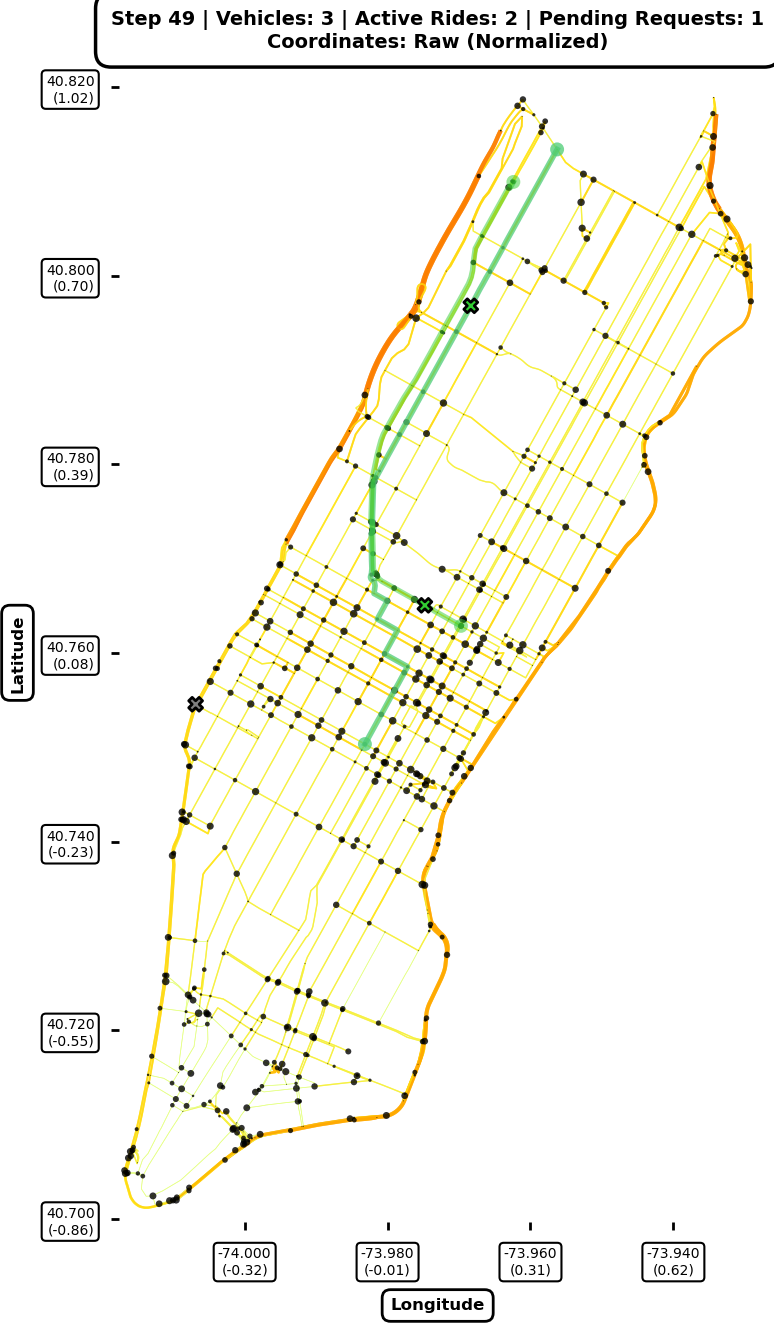

In [715]:
fig, ax = env.render()
fig